# 1. Entendimiento del problema

Garment Industry es una compañia del sector textil con muchas actividades manuales. Su exito está en que las prendas son "hechas a mano", por lo que medir la productividad de sus empleados se vuelve esencial para mejorar las utilidades de la organización. Es por esto que la compañía quiere estimar los niveles de productividad de sus empleados para mejorar la operación y mantener los ingresos esperados, ademas identificar herramientas para mejorar el dia a dia de sus empleados

# 2. Enfoque analítico

Construir un modelo de regresión para predecir la productividad de cada empleado con un MAPE menor al 20% (Probabilidad superior al 80%)

# 3. Requerimientos de Datos
- Se requieren datos del trabajador en su puesto de trabajo particular.
- Se requieren mediciones del puesto de trabajo (tiempos, cantidad de prendas, momentos de ocio, cantidad de personas).
- Se requiere una medición inicial de la productividad.

# 4. Recolección de Datos
- date: Fecha de medición de la productividad.
- quarter: Trimestre de la medición.
- department: Area de trabajo en particular.
- day: Nombre del dia en el que se hizo la medición.
- team: Numero del equipo de trabajo.
- target_productivity: Productividad objetivo del area de trabajo.
- smv: Valor de tiempo estandar en minutos de la actividad.
- wip: Cantidad de trabajo en proceso (unidades).
- over_time: Tiempo en general de operación.
- incentive: Porcentaje de incentivos al área de trabajo.
- idle_time: Tiempo de parada.
- idle_men: Cantidad de trabajadores quieros en el tiempo de parada.
- no_of_style_change: Cantidad de cambios de estilo en la producción.
- no_of_workers: Cantidad total de trabajadores.
- actual_productivity: Productividad actual (**Y**).

In [2]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv('garments_worker_productivity.csv')
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

# 5. Entendimiento de los Datos
- Conocer nuestra variable y
- Identificar datos nulos
- Analisis univariado y multivariado

In [4]:
import matplotlib.pyplot as plt
import seaborn as sb

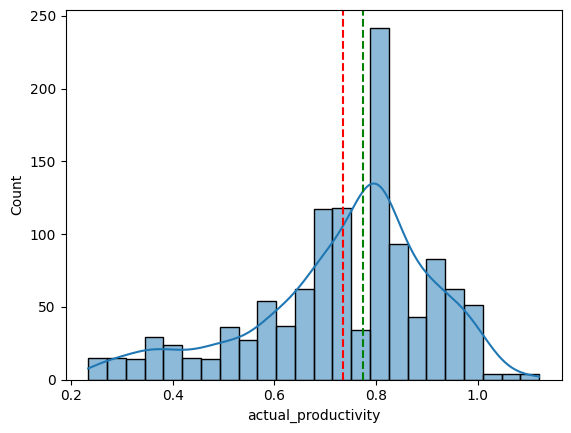

In [5]:
sb.histplot(data = data, x = 'actual_productivity', kde = True)
plt.axvline(x = data['actual_productivity'].mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data['actual_productivity'].median(), color = 'green', linestyle = 'dashed')
plt.show()

## Datos nulos

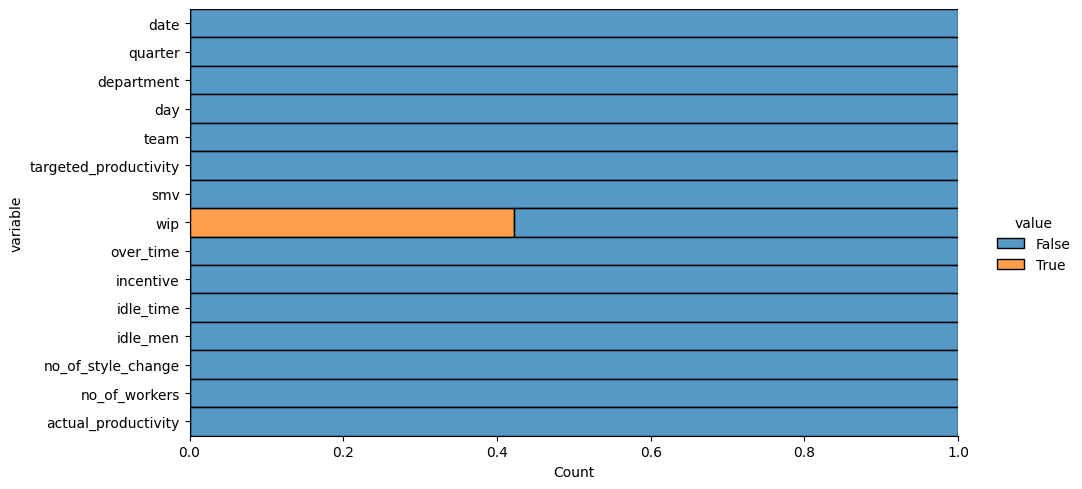

In [6]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

## Exploración univariada de los datos

### Variables numericas

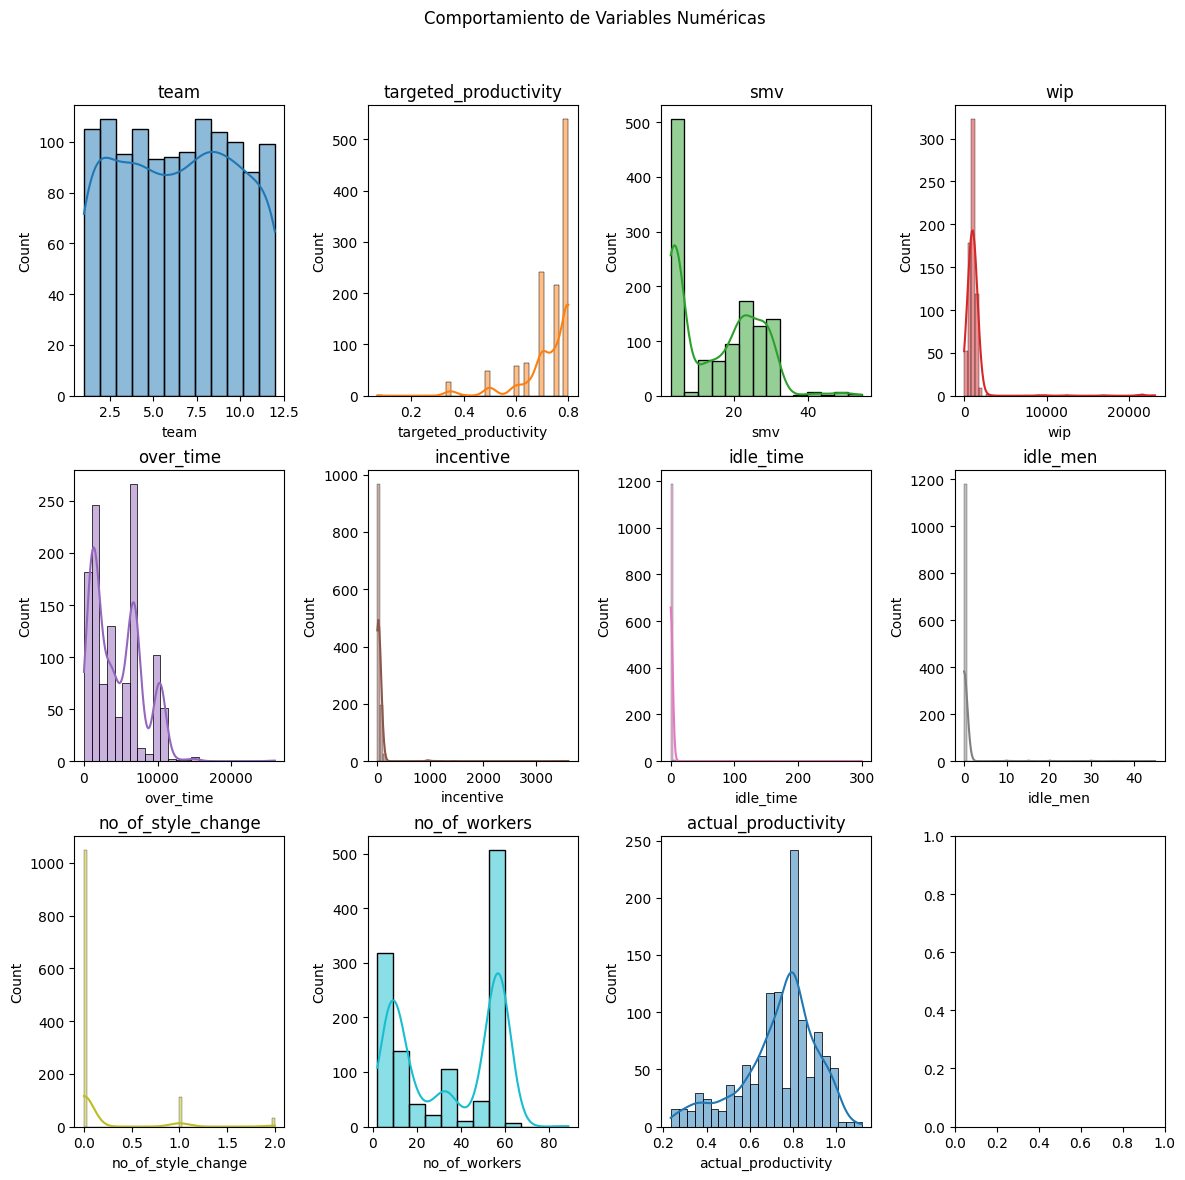

In [7]:
fig, ax = plt.subplots(3, 4, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns

for i, col in enumerate(num_col):
  sb.histplot(
    data = data,
    x = col, 
    kde = True,
    color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
    ax = ax[i]
  )
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

### Variables categoricas

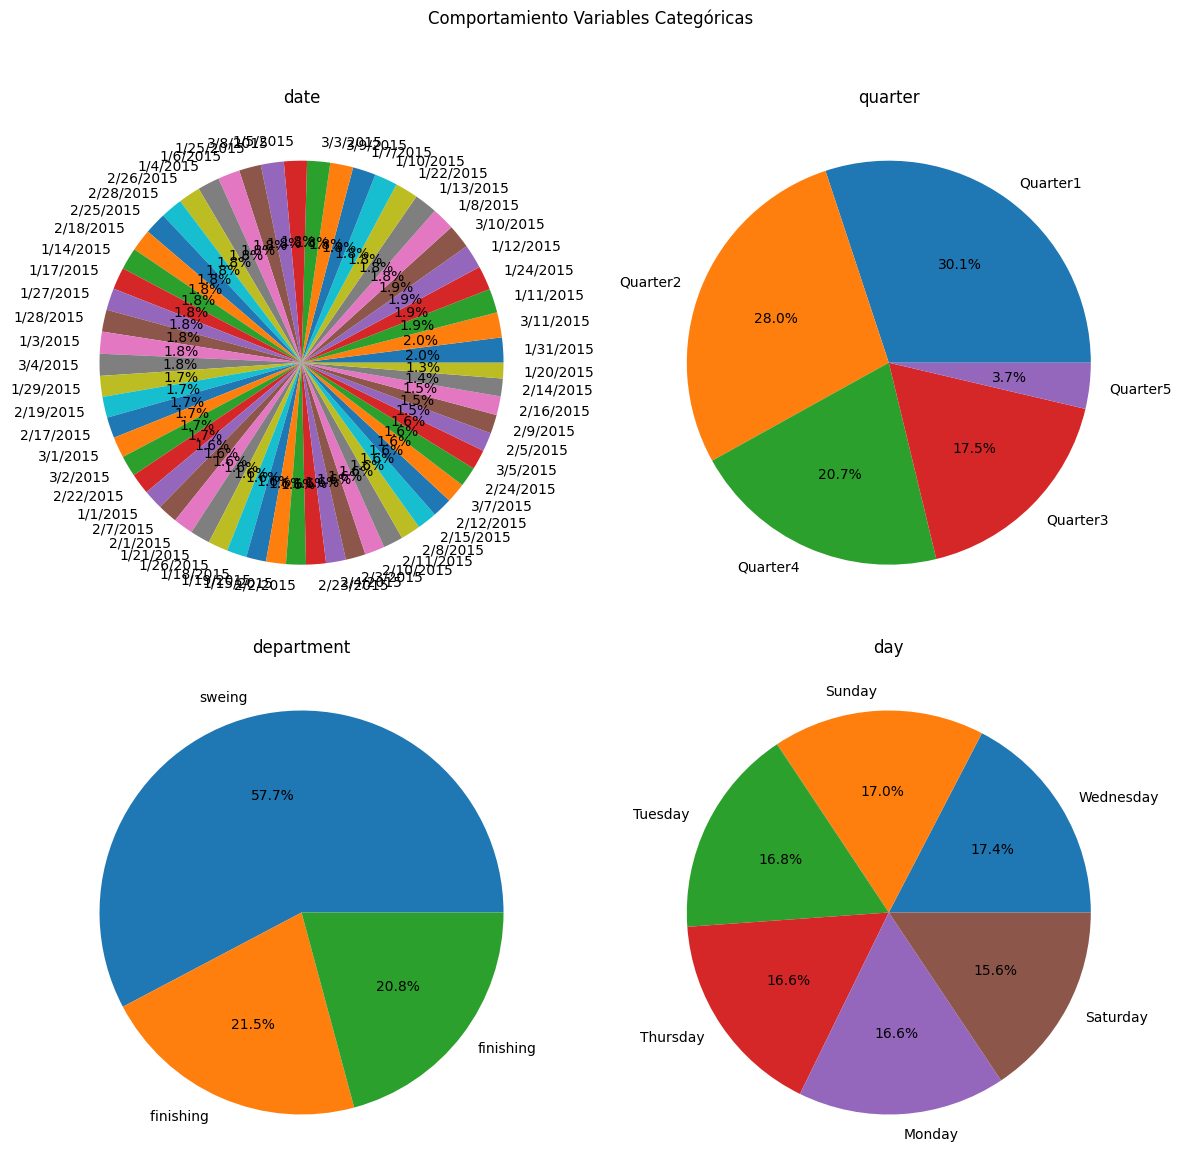

In [8]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns

for i, col in enumerate(cat_col):
  ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

## Correlacion

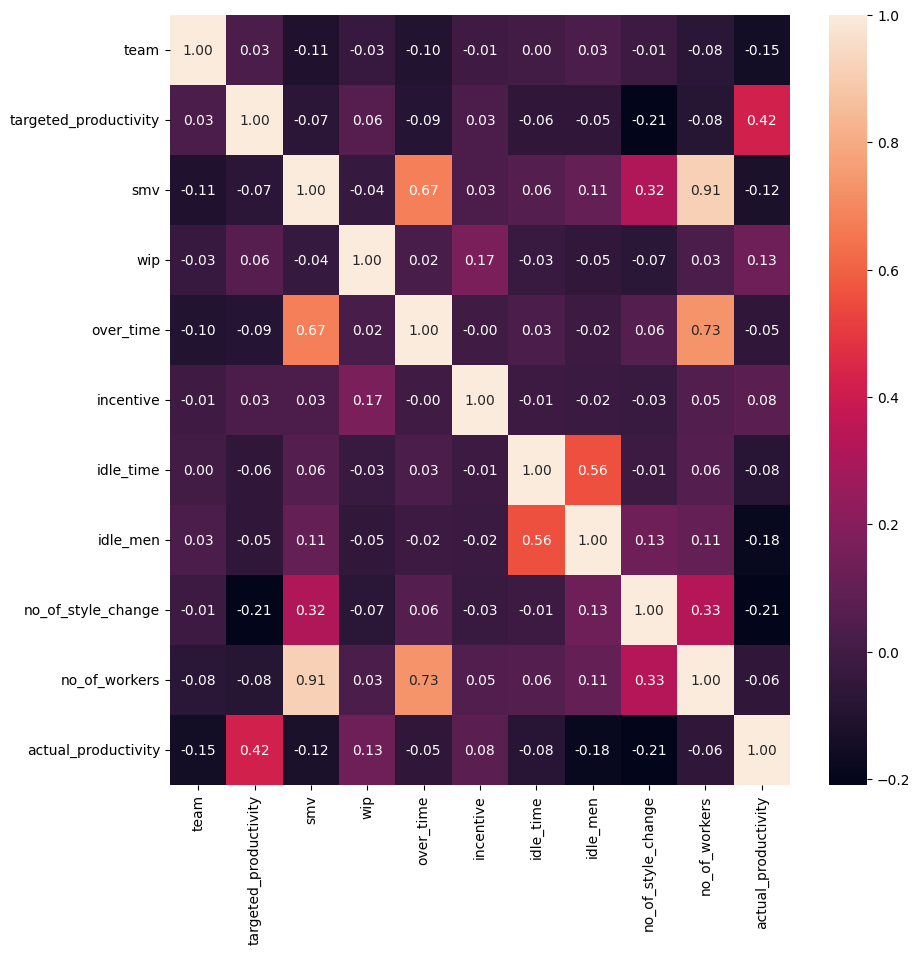

In [9]:
plt.figure(figsize=(10, 10))
sb.heatmap(data.corr(numeric_only = True), annot=True, fmt='.2f')
plt.show()

# 6. Preparación de los Datos

## Completar variables que cuentan con datos nulos (modelo recursivo)

In [10]:
import sklearn

categorical_cols = data.select_dtypes(include = ['object']).columns
categorical_transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_cols),
    remainder = 'passthrough'
)
categorical_transformer

,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [11]:
data_transformed = pd.DataFrame(
  categorical_transformer.fit_transform(data),
  columns=categorical_transformer.get_feature_names_out(),
  index=data.index
).rename(
  columns=lambda x: x.removeprefix('ordinalencoder__')
).rename(
  columns=lambda x: x.removeprefix('remainder__')
)

data_transformed

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,0.0,0.0,2.0,3.0,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,0.0,0.0,1.0,3.0,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,0.0,0.0,2.0,3.0,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,0.0,0.0,2.0,3.0,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
4,0.0,0.0,2.0,3.0,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,51.0,1.0,0.0,5.0,10.0,0.75,2.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.628333
1193,51.0,1.0,0.0,5.0,8.0,0.70,3.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.625625
1194,51.0,1.0,0.0,5.0,7.0,0.65,3.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.625625
1195,51.0,1.0,0.0,5.0,9.0,0.75,2.90,NaN,1800.0,0.0,0.0,0.0,0.0,15.0,0.505889


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer

recursive_imputer = sklearn.impute.IterativeImputer(estimator = DecisionTreeRegressor(),
                                                    initial_strategy = 'mean',
                                                    max_iter = 10)
data_recursive_df = pd.DataFrame(recursive_imputer.fit_transform(data_transformed).round(2),
                                 columns = data_transformed.columns,
                                 index = data_transformed.index)
data_recursive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   float64
 1   quarter                1197 non-null   float64
 2   department             1197 non-null   float64
 3   day                    1197 non-null   float64
 4   team                   1197 non-null   float64
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   float64
 9   incentive              1197 non-null   float64
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   float64
 12  no_of_style_change     1197 non-null   float64
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [13]:
data_imputed = data_recursive_df.copy()
data_imputed[categorical_cols] = (categorical_transformer.named_transformers_.ordinalencoder.inverse_transform(X = data_recursive_df[categorical_cols]))
data_imputed

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.94
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.89
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10.0,0.75,2.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1193,3/11/2015,Quarter2,finishing,Wednesday,8.0,0.70,3.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1194,3/11/2015,Quarter2,finishing,Wednesday,7.0,0.65,3.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1195,3/11/2015,Quarter2,finishing,Wednesday,9.0,0.75,2.90,434.0,1800.0,0.0,0.0,0.0,0.0,15.0,0.51


In [14]:
data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   float64
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   float64
 9   incentive              1197 non-null   float64
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   float64
 12  no_of_style_change     1197 non-null   float64
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [15]:
data_imputed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.00,3.00,6.00,9.00,12.00
targeted_productivity,1197.0,0.729632,0.097891,0.07,0.70,0.75,0.80,0.80
smv,1197.0,15.062172,10.943219,2.90,3.94,15.26,24.26,54.56
wip,1197.0,1181.456140,2197.239155,7.00,680.00,959.00,1216.00,23122.00
over_time,1197.0,4567.460317,3348.823563,0.00,1440.00,3960.00,6960.00,25920.00
incentive,1197.0,38.210526,160.182643,0.00,0.00,0.00,50.00,3600.00
idle_time,1197.0,0.730159,12.709757,0.00,0.00,0.00,0.00,300.00
idle_men,1197.0,0.369256,3.268987,0.00,0.00,0.00,0.00,45.00
no_of_style_change,1197.0,0.150376,0.427848,0.00,0.00,0.00,0.00,2.00
no_of_workers,1197.0,34.609858,22.197687,2.00,9.00,34.00,57.00,89.00


## Eliminar variables que no son significativas

In [16]:
data_mod = data_imputed.drop(columns = ['team', 'no_of_style_change', 'no_of_workers', 'incentive', 'idle_men'], axis = 1)

## Ajustar variable department

In [17]:
data_mod['department'].replace({ 'finishing ': 'finishing' }, inplace = True)

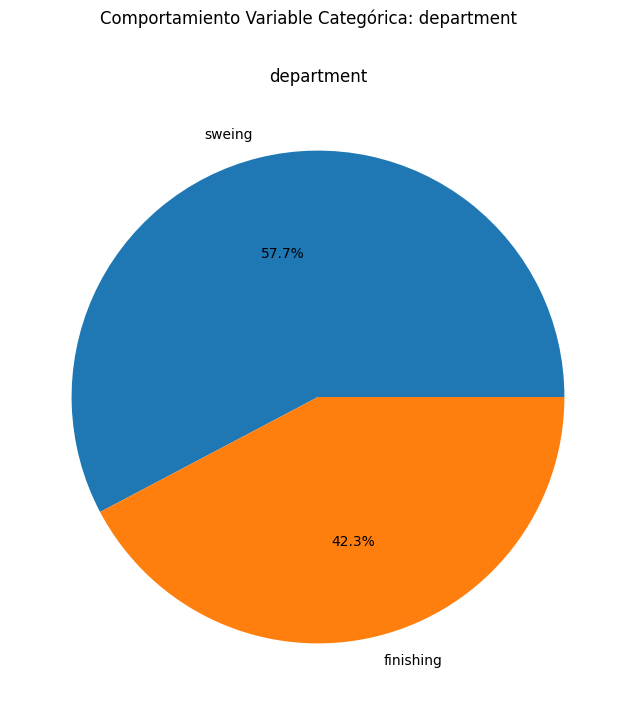

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
  x=data_mod['department'].value_counts(),
  labels=data_mod['department'].value_counts().index,
  autopct='%0.1f%%'
)
ax.set_title('department')
fig.suptitle("Comportamiento Variable Categórica: department")
plt.show()


## Manejo variables tipo fecha

In [19]:
data_mod['date'] = pd.to_datetime(data_mod['date'], format='%m/%d/%Y')

data_mod['num_day'] = [i.day for i in data_mod.date]
data_mod['num_month'] = [i.month for i in data_mod.date]

data_mod.drop(columns = ['date'], axis = 1, inplace = True)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   targeted_productivity  1197 non-null   float64
 4   smv                    1197 non-null   float64
 5   wip                    1197 non-null   float64
 6   over_time              1197 non-null   float64
 7   idle_time              1197 non-null   float64
 8   actual_productivity    1197 non-null   float64
 9   num_day                1197 non-null   int64  
 10  num_month              1197 non-null   int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 103.0+ KB


## Pipeline

In [20]:
# Transformaciones de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

In [21]:
num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = data_mod.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder())])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
  ],
  remainder='passthrough'
)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [22]:
data_pre = preprocessor.fit_transform(data_mod)

cod_cat = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])

data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro

,targeted_productivity,smv,wip,over_time,idle_time,actual_productivity,num_day,num_month,quarter_Quarter1,quarter_Quarter2,...,quarter_Quarter4,quarter_Quarter5,department_finishing,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,1.000000,0.450252,0.047631,0.273148,0.0,0.797753,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.931507,0.020132,0.034869,0.037037,0.0,0.741573,0.000000,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.000000,0.164731,0.041575,0.141204,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.000000,0.164731,0.041575,0.141204,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.000000,0.445219,0.050314,0.074074,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,0.931507,0.000000,0.018473,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1193,0.863014,0.019357,0.018473,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1194,0.794521,0.019357,0.018473,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1195,0.931507,0.000000,0.018473,0.069444,0.0,0.314607,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Separacion variables X y Y

In [23]:
X = data_pro.drop(columns = ['actual_productivity'], axis = 1)
y = data_pro['actual_productivity']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=123)
print(f'El tamaño del conjunto de prueba es: {X_test.shape} {y_test.shape}')
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}')

El tamaño del conjunto de prueba es: (838, 20) (838,)
El tamaño del conjunto de entrenamiento es: (359, 20) (359,)


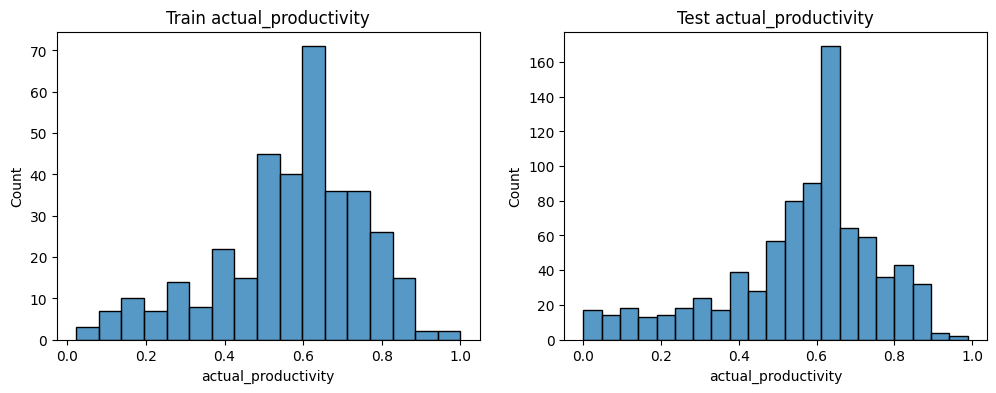

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sb.histplot(y_train, ax=ax[0])
ax[0].set_title('Train actual_productivity')

sb.histplot(y_test, ax=ax[1])
ax[1].set_title('Test actual_productivity')

plt.show()

# 7. Modelado

- Regresion lineal
- K vecinos mas cercanos
- Maquina de soporte vectorial
- Arboles de decision
- Random Forest
- Gradient Boosting
- Percepcion Multicapa

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Regresion lineal

In [27]:
modelo_1 = LinearRegression()
modelo_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
modelo_1.coef_

array([ 0.47301993, -0.08029884,  0.2033758 ,  0.11462085, -0.17353389,
        0.28770397, -0.01436281,  0.12915748,  0.07171192, -0.02771742,
       -0.12573564, -0.04741635,  0.01453107, -0.01453107, -0.01259679,
        0.00087989,  0.00484609, -0.01312357,  0.02879957, -0.00880518])

In [29]:
modelo_1.intercept_

np.float64(0.0037995033304285553)

## K Vecinos más cercanos

In [30]:
modelo_2 = KNeighborsRegressor()

param_grid = {
  'n_neighbors': [2, 5, 9, 15, 25, 40, 35],
  'p': [1, 2],
}

reg_2 = GridSearchCV(estimator=modelo_2, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_2.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_2.cv_results_['params']),
    pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,n_neighbors,p,MAPE
7,15,2,-0.520081
5,9,2,-0.521627
4,9,1,-0.521725
6,15,1,-0.522792
8,25,1,-0.532647
9,25,2,-0.534468
10,40,1,-0.539325
12,35,1,-0.539755
11,40,2,-0.540080
13,35,2,-0.540880


In [31]:
modelo_2_final = reg_2.best_estimator_
modelo_2_final

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Maquina de soporte Vectorial

In [32]:
modelo_3 = SVR()

param_grid = {
  'C': [0, 0.01, 1, 10, 100],
  'kernel': ['linear', 'poly', 'rbf'],
  'degree': [2, 3]
}

reg_3 = GridSearchCV(estimator=modelo_3, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_3.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_3.cv_results_['params']),
    pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,C,degree,kernel,MAPE
25,100.00,2,poly,-0.479044
19,10.00,2,poly,-0.486591
29,100.00,3,rbf,-0.498429
26,100.00,2,rbf,-0.498429
22,10.00,3,poly,-0.503558
16,1.00,3,poly,-0.505026
13,1.00,2,poly,-0.506226
24,100.00,2,linear,-0.506429
27,100.00,3,linear,-0.506429
15,1.00,3,linear,-0.506881


In [33]:
modelo_3_final = reg_3.best_estimator_
modelo_3_final

,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Arbol de Regresion

In [34]:
modelo_4 = DecisionTreeRegressor(random_state=123)

param_grid = {
  'criterion': ['friedman_mse', 'poisson', 'squared_error', 'absolute_error'],
  'max_depth': [None, 5, 6, 3, 4, 10, 100],
  'max_leaf_nodes': [None, 2, 3, 4]
}

reg_4 = GridSearchCV(estimator=modelo_4, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_4.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_4.cv_results_['params']),
    pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,criterion,max_depth,max_leaf_nodes,MAPE
100,absolute_error,4.0,NaN,-0.408863
88,absolute_error,5.0,NaN,-0.418699
92,absolute_error,6.0,NaN,-0.419843
84,absolute_error,NaN,NaN,-0.422955
108,absolute_error,100.0,NaN,-0.422955
...,...,...,...,...
89,absolute_error,5.0,2.0,-0.498063
101,absolute_error,4.0,2.0,-0.498063
97,absolute_error,3.0,2.0,-0.498063
105,absolute_error,10.0,2.0,-0.498063


In [35]:
modelo_4_final = reg_4.best_estimator_
modelo_4_final

,criterion,'absolute_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Bosque Aleatorio

In [36]:
modelo_5 = RandomForestRegressor(random_state=123)

param_grid = {
  'n_estimators': [100, 200, 500],
  'criterion': ['friedman_mse', 'poisson', 'squared_error', 'absolute_error'],
  'max_depth': [None, 5, 6, 3, 4, 10, 100],
  'max_leaf_nodes': [None, 2, 3, 5]
}

reg_5 = GridSearchCV(estimator=modelo_5, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_5.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_5.cv_results_['params']),
    pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,criterion,max_depth,max_leaf_nodes,n_estimators,MAPE
84,poisson,NaN,NaN,100,-0.391854
156,poisson,100.0,NaN,100,-0.391854
240,squared_error,100.0,NaN,100,-0.392141
168,squared_error,NaN,NaN,100,-0.392141
0,friedman_mse,NaN,NaN,100,-0.392789
...,...,...,...,...,...
269,absolute_error,5.0,2.0,500,-0.494658
281,absolute_error,6.0,2.0,500,-0.494658
329,absolute_error,100.0,2.0,500,-0.494658
293,absolute_error,3.0,2.0,500,-0.494658


In [37]:
modelo_5_final = reg_5.best_estimator_
modelo_5_final

,n_estimators,100
,criterion,'poisson'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Adaptative Boosting

In [38]:
modelo_6 = AdaBoostRegressor()

param_grid = {
  'n_estimators': [100, 200, 400, 600],
  'loss': ['linear', 'square', 'exponential'],
  'learning_rate': [0.001, 0.1, 1, 10]
}

reg_6 = GridSearchCV(estimator=modelo_6, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_6.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_6.cv_results_['params']),
    pd.DataFrame(reg_6.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,learning_rate,loss,n_estimators,MAPE
2,0.001,linear,400,-0.435547
6,0.001,square,400,-0.435798
10,0.001,exponential,400,-0.436224
7,0.001,square,600,-0.437696
13,0.100,linear,200,-0.437852
9,0.001,exponential,200,-0.438118
11,0.001,exponential,600,-0.438349
3,0.001,linear,600,-0.439134
0,0.001,linear,100,-0.439438
16,0.100,square,100,-0.440418


In [39]:
modelo_6_final = reg_6.best_estimator_
modelo_6_final

,estimator,None
,n_estimators,400
,learning_rate,0.001
,loss,'linear'
,random_state,None


## Gradiant Boosting

In [40]:
modelo_7 = GradientBoostingRegressor()

param_grid = {
  'n_estimators': [100, 200, 400, 500, 1000],
  'loss': ['squared_error', 'absolute_error'],
  'criterion': ['friedman_mse', 'squared_error'],
}

reg_7 = GridSearchCV(estimator=modelo_7, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_7.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_7.cv_results_['params']),
    pd.DataFrame(reg_7.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,criterion,loss,n_estimators,MAPE
11,squared_error,squared_error,200,-0.383374
2,friedman_mse,squared_error,400,-0.389557
14,squared_error,squared_error,1000,-0.389588
1,friedman_mse,squared_error,200,-0.390136
3,friedman_mse,squared_error,500,-0.390240
13,squared_error,squared_error,500,-0.390873
10,squared_error,squared_error,100,-0.391093
0,friedman_mse,squared_error,100,-0.391590
9,friedman_mse,absolute_error,1000,-0.396082
12,squared_error,squared_error,400,-0.396123


In [41]:
modelo_7_final = reg_7.best_estimator_
modelo_7_final

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'squared_error'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Perceptor multicapa

In [53]:
modelo_8 = MLPRegressor(random_state=123)

param_grid = {
  'hidden_layer_sizes': [(10,), (10,10,), (10,10,10,), (20,10,)],
  'activation': ['relu', 'tanh', 'logistic'],
  'solver': ['adam', 'sgd', 'lbfgs'],
  'max_iter': [200, 300, 400],
  'learning_rate_init': [0.001, 0.01, 0.1, 1, 10]
}

reg_8 = GridSearchCV(estimator=modelo_8, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_8.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_8.cv_results_['params']),
    pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,activation,hidden_layer_sizes,learning_rate_init,max_iter,solver,MAPE
497,logistic,"(20, 10)",0.001,200,lbfgs,-4.667902e-01
515,logistic,"(20, 10)",0.100,200,lbfgs,-4.667902e-01
506,logistic,"(20, 10)",0.010,200,lbfgs,-4.667902e-01
524,logistic,"(20, 10)",1.000,200,lbfgs,-4.667902e-01
533,logistic,"(20, 10)",10.000,200,lbfgs,-4.667902e-01
...,...,...,...,...,...,...
82,relu,"(10, 10)",10.000,200,sgd,-5.585726e+57
85,relu,"(10, 10)",10.000,300,sgd,-5.585726e+57
127,relu,"(10, 10, 10)",10.000,200,sgd,NaN
130,relu,"(10, 10, 10)",10.000,300,sgd,NaN


In [54]:
modelo_8_final = reg_8.best_estimator_
modelo_8_final

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


# 8. Validacion

- Ajuste cuadrfatico
- Raiz del error cuadratico medio
- Error medio absoluto
- Porcentaje del error medio absoluto

## Funciones de validacion

In [42]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

def predecir_y_desescalar(modelo, X_train, X_test, y_train, y_test, y_total):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    y_min, y_max = np.min(y_total), np.max(y_total)
    pred_train_des = pred_train * (y_max - y_min) + y_min
    pred_test_des = pred_test * (y_max - y_min) + y_min
    y_train_des = y_train * (y_max - y_min) + y_min
    y_test_des = y_test * (y_max - y_min) + y_min
    return pred_train_des, pred_test_des, y_train_des, y_test_des

def mostrar_metricas(y_train_des, pred_train_des, y_test_des, pred_test_des, nombre_modelo="Modelo"):
    # Entrenamiento
    r2_train = r2_score(y_train_des, pred_train_des)
    rmse_train = root_mean_squared_error(y_train_des, pred_train_des)
    mae_train = mean_absolute_error(y_train_des, pred_train_des)
    mape_train = mean_absolute_percentage_error(y_train_des, pred_train_des) * 100

    print(f"Las métricas de desempeño en entrenamiento para {nombre_modelo} son:")
    print(f"R2: {r2_train}")
    print(f"RMSE: {rmse_train}")
    print(f"MAE: {mae_train}")
    print(f"MAPE: {mape_train / 100}")

    sb.histplot(data=y_train_des, label='Datos de entrenamiento')
    sb.histplot(pred_train_des, label='Predicciones de entrenamiento')
    plt.legend()
    plt.show()

    # Test
    r2_test = r2_score(y_test_des, pred_test_des)
    rmse_test = root_mean_squared_error(y_test_des, pred_test_des)
    mae_test = mean_absolute_error(y_test_des, pred_test_des)
    mape_test = mean_absolute_percentage_error(y_test_des, pred_test_des) * 100

    print(f"Las métricas de desempeño en test para {nombre_modelo} son:")
    print(f"R2: {r2_test}")
    print(f"RMSE: {rmse_test}")
    print(f"MAE: {mae_test}")
    print(f"MAPE: {mape_test / 100}")

    sb.histplot(data=y_test_des, label='Datos de test')
    sb.histplot(pred_test_des, label='Predicciones de test')
    plt.legend()
    plt.show()

## Regresion lineal

Las métricas de desempeño en entrenamiento para Regresión Lineal son:
R2: 0.193958845117414
RMSE: 0.1660509517101361
MAE: 0.12001737093287898
MAPE: 0.461079216024253


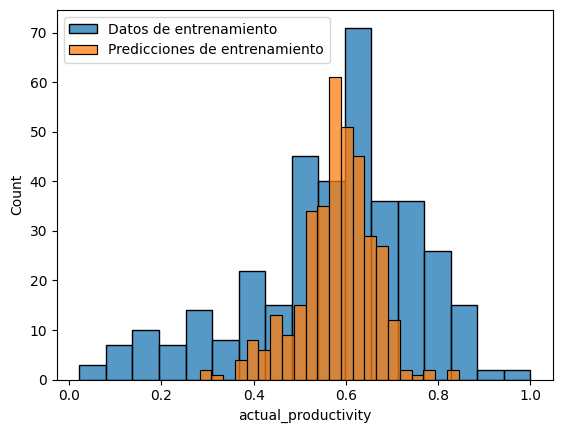

Las métricas de desempeño en test para Regresión Lineal son:
R2: 0.19851644299077964
RMSE: 0.17916338497584877
MAE: 0.12873242440471047
MAPE: 2759537123071.0854


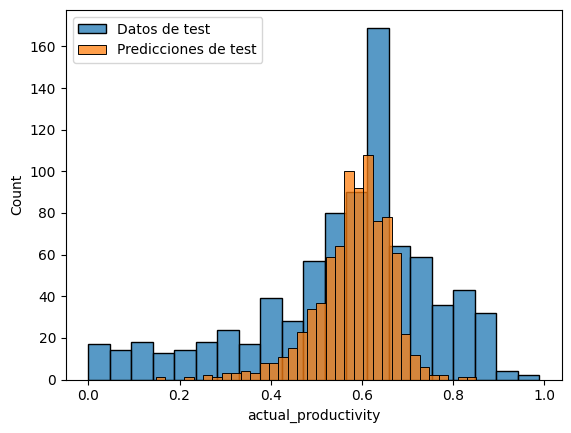

In [43]:
pred_train_1, pred_test_1, y_train_des, y_test_des = predecir_y_desescalar(modelo_1, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_1, y_test_des, pred_test_1, nombre_modelo="Regresión Lineal")

## K Vecinos mas cercanos

Las métricas de desempeño en entrenamiento para KNN son:
R2: 0.20463856320084073
RMSE: 0.1649472297018502
MAE: 0.12631007897509727
MAPE: 0.48273197283148706


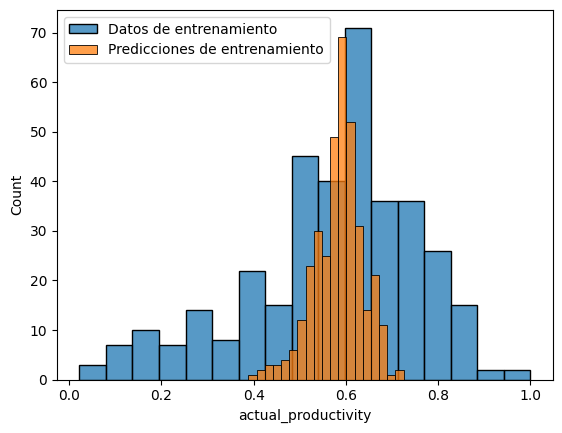

Las métricas de desempeño en test para KNN son:
R2: 0.06879834729049505
RMSE: 0.1931184733954681
MAE: 0.14310780974855417
MAPE: 3135970350059.9346


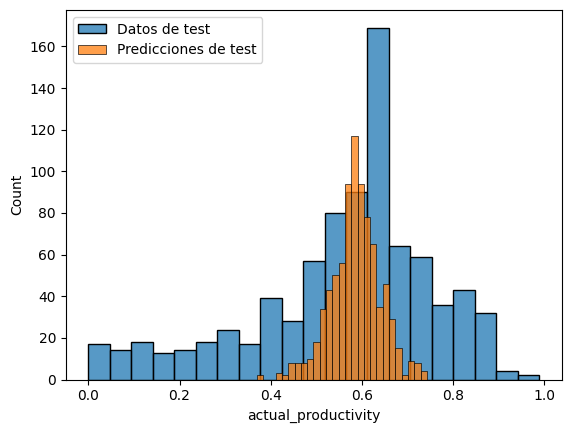

In [44]:
pred_train_2, pred_test_2, y_train_des, y_test_des = predecir_y_desescalar(modelo_2_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_2, y_test_des, pred_test_2, nombre_modelo="KNN")

## Maquina de Soporte Vectorial

Las métricas de desempeño en entrenamiento para MSV son:
R2: 0.5134773476497008
RMSE: 0.12900730227654061
MAE: 0.0952600501593884
MAPE: 0.34750344351675155


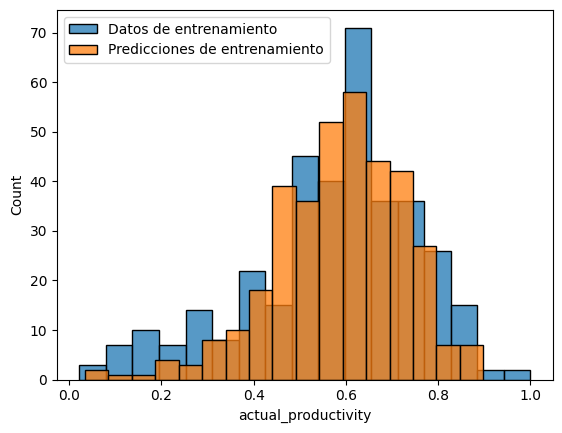

Las métricas de desempeño en test para MSV son:
R2: -0.02558046183899365
RMSE: 0.20266876446571871
MAE: 0.15031419856920145
MAPE: 915682371210.2991


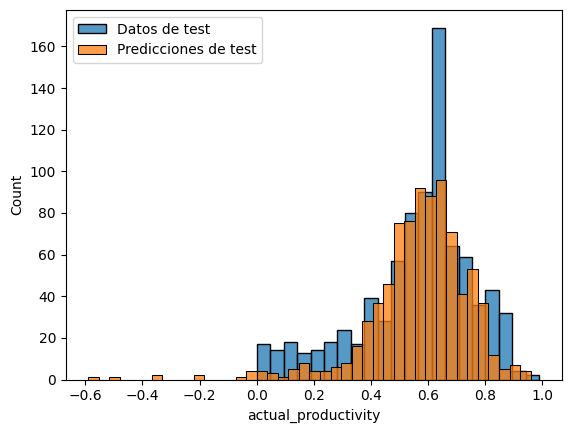

In [45]:
pred_train_3, pred_test_3, y_train_des, y_test_des = predecir_y_desescalar(modelo_3_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_3, y_test_des, pred_test_3, nombre_modelo="MSV")

## Arbol de Regresion

Las métricas de desempeño en entrenamiento para Arbol Regresion son:
R2: 0.4122727797538853
RMSE: 0.14179165231042284
MAE: 0.08822885042721665
MAPE: 0.3653089646414786


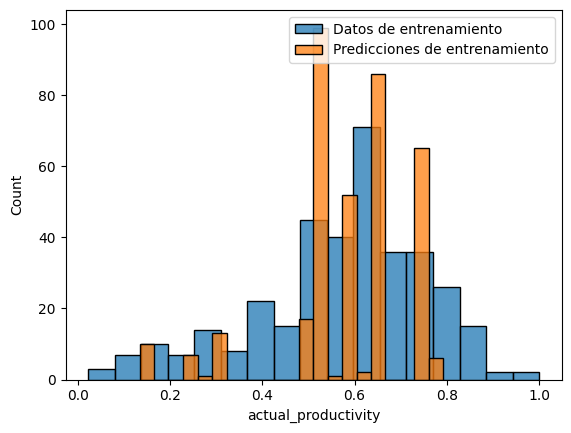

Las métricas de desempeño en test para Arbol Regresion son:
R2: 0.21613996754192144
RMSE: 0.17718265748548925
MAE: 0.11115282507843711
MAPE: 2838073294983.575


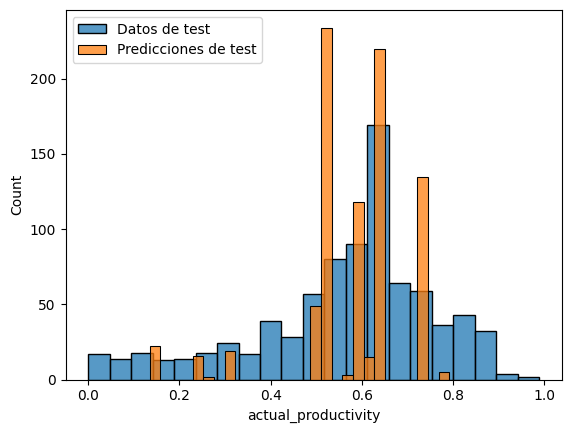

In [46]:
pred_train_4, pred_test_4, y_train_des, y_test_des = predecir_y_desescalar(modelo_4_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_4, y_test_des, pred_test_4, nombre_modelo="Arbol Regresion")

## Bosque aleatorio

Las métricas de desempeño en entrenamiento para Random Forest son:
R2: 0.9146543364038221
RMSE: 0.05403230447252886
MAE: 0.036204443262078376
MAPE: 0.13706268685799783


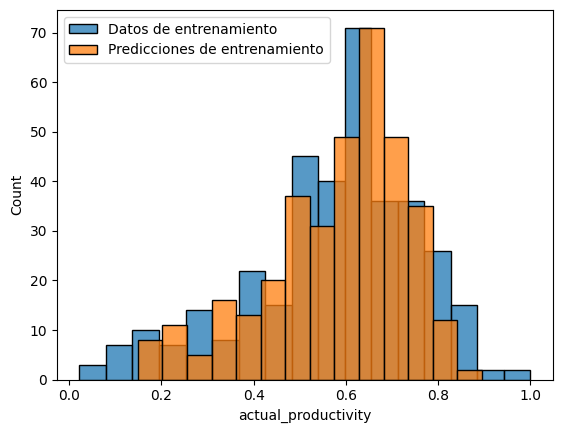

Las métricas de desempeño en test para Random Forest son:
R2: 0.3810617409483922
RMSE: 0.15744381883134295
MAE: 0.10437230482013407
MAPE: 2503542953404.702


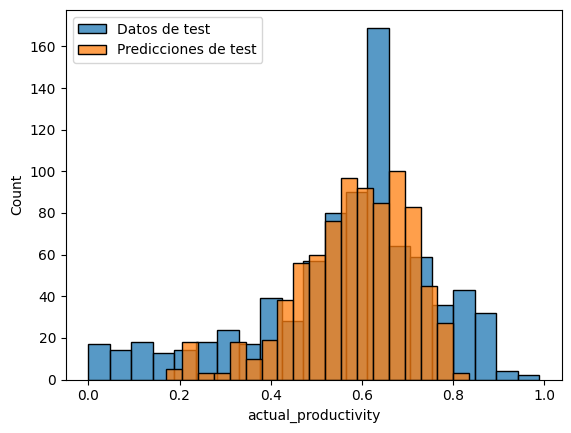

In [47]:
pred_train_5, pred_test_5, y_train_des, y_test_des = predecir_y_desescalar(modelo_5_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_5, y_test_des, pred_test_5, nombre_modelo="Random Forest")

## Adaptative Boosting

Las métricas de desempeño en entrenamiento para Adaptative Boosting son:
R2: 0.44422405989339087
RMSE: 0.13788360567868782
MAE: 0.09674213579308474
MAPE: 0.38118859546846356


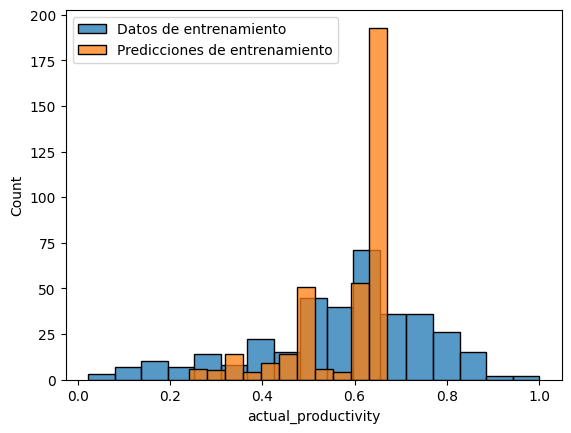

Las métricas de desempeño en test para Adaptative Boosting son:
R2: 0.2554274328847095
RMSE: 0.17268533847414258
MAE: 0.11628139435895482
MAPE: 2729381126239.5996


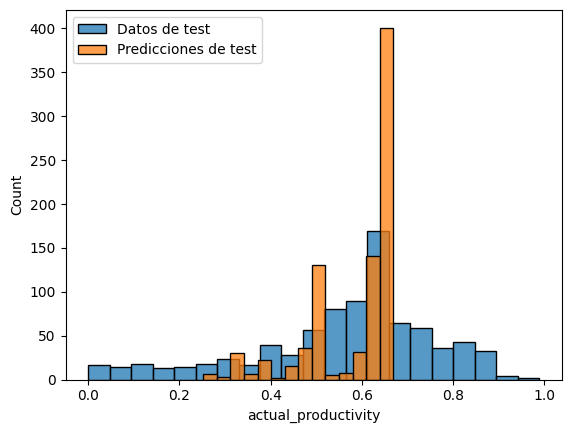

In [48]:
pred_train_6, pred_test_6, y_train_des, y_test_des = predecir_y_desescalar(modelo_6_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_6, y_test_des, pred_test_6, nombre_modelo="Adaptative Boosting")

## Gradient Boosting

Las métricas de desempeño en entrenamiento para Gradient Boosting son:
R2: 0.8836456116889122
RMSE: 0.06308907275528099
MAE: 0.04358238849288833
MAPE: 0.13978300974234703


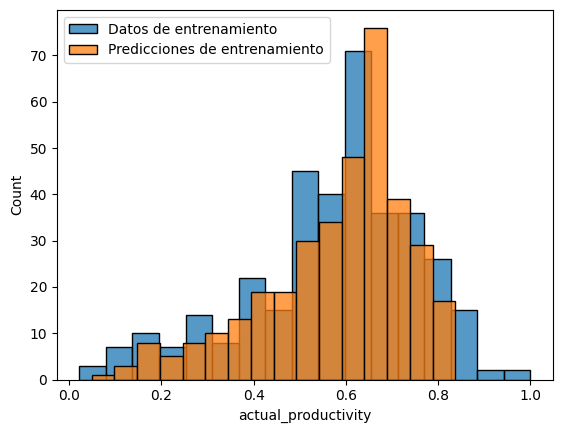

Las métricas de desempeño en test para Gradient Boosting son:
R2: 0.4390084139307394
RMSE: 0.14989257638906195
MAE: 0.10014949676766721
MAPE: 2451448132486.7983


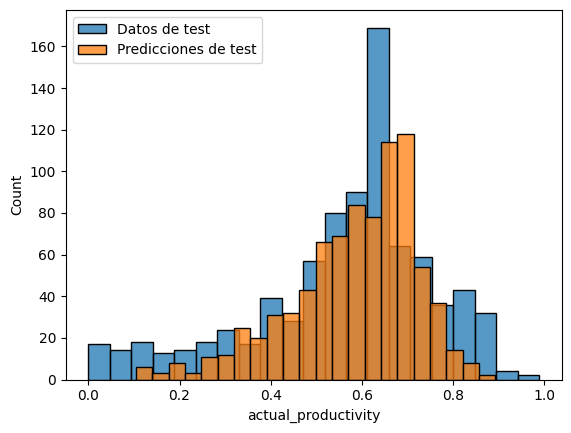

In [49]:
pred_train_7, pred_test_7, y_train_des, y_test_des = predecir_y_desescalar(modelo_7_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_7, y_test_des, pred_test_7, nombre_modelo="Gradient Boosting")

## Perceptor multicapa

Las métricas de desempeño en entrenamiento para Perceptor Multicapa son:
R2: 0.37233674726618116
RMSE: 0.14652985246519334
MAE: 0.10498240660820116
MAPE: 0.3984021892893939


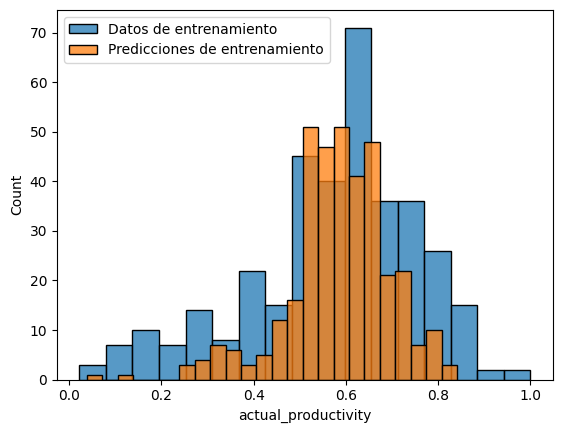

Las métricas de desempeño en test para Perceptor Multicapa son:
R2: 0.17614229576521356
RMSE: 0.18164692665009394
MAE: 0.12938399767329045
MAPE: 2582060597254.4478


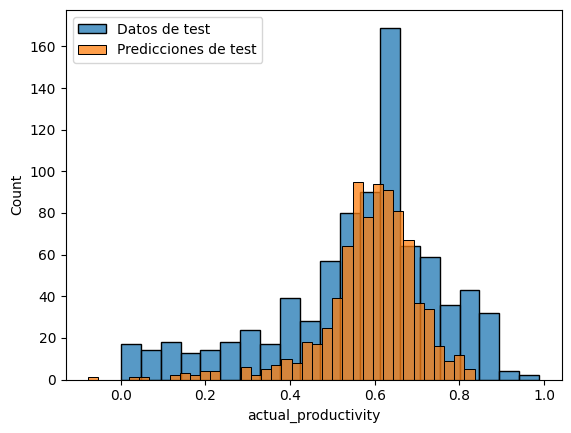

In [55]:
pred_train_8, pred_test_8, y_train_des, y_test_des = predecir_y_desescalar(modelo_8_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_8, y_test_des, pred_test_8, nombre_modelo="Perceptor Multicapa")